In [3]:
from bamboo_hh.variables import REG 
from utils.histograms import normalize_hist, get_process_hists, add_hists
from utils import functions
from references import AnalysisConfig, Reference
from llr_study.utils import format_label_for_matplotlib

import numpy as np
import matplotlib.pyplot as plt
import mplhep
from pathlib import Path
import json

plt.style.use(mplhep.style.CMS)
label_fontsize = 18
tick_fontsize = 18
rlabel = "13.6 TeV"
legend_fontsize = 18
cms_fontsize = 18
ylabel = "normalized events"

In [4]:
%config InlineBackend.figure_format = 'retina'

## JetTop_crtd_even

In [5]:
def hist_to_numpy(hist):
    values = np.array([hist.GetBinContent(i + 1) for i in range(hist.GetNbinsX())])
    edges = np.array([hist.GetBinLowEdge(i + 1) for i in range(hist.GetNbinsX() + 1)])
    return values, edges

def plot_signal_background(signal_hist, background_hist, xlabel=None, xmin=None, xmax=None, save_to=None):

    normalized_signal = normalize_hist(signal_hist)
    normalized_background = normalize_hist(background_hist)

    sig_vals, edges = hist_to_numpy(normalized_signal)
    bkg_vals, _ = hist_to_numpy(normalized_background)

    print(len(sig_vals))
    fig, ax = plt.subplots(figsize=(6.5, 6))  # Square-ish

    ax.step(edges[:-1], sig_vals, where='post', color='blue', linewidth=2.0, label="Signal")
    ax.fill_between(edges[:-1], sig_vals, step='post', color='blue', alpha=0.2)

    ax.step(edges[:-1], bkg_vals, where='post', color='red', linewidth=2.0, label="Background")
    ax.fill_between(edges[:-1], bkg_vals, step='post', color='red', alpha=0.2)

    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    # ax.set_xlabel(reference.observable_base, fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, max(sig_vals.max(), bkg_vals.max()) * 1.2)
    ax.grid(True)

    ax.legend(fontsize=legend_fontsize, loc="upper right", frameon=True)

    mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=cms_fontsize, loc=0)
    ax.text(
        1.0, 1.0, rlabel,
        transform=ax.transAxes,
        fontsize=cms_fontsize,
        horizontalalignment='right',
        verticalalignment='bottom'
    )

    fig.tight_layout()
    if save_to:
        plt.savefig(save_to, dpi=300, bbox_inches='tight')
        print(f"Distribution sig/bkg saved to {save_to}")
    plt.show()


def load_lr_mapping(json_path: str, name: str):
    with open(json_path, "r") as f:
        data = json.load(f)

    for corr in data["corrections"]:
        if corr["name"] == name:
            edges = np.array(corr["data"]["edges"])
            values = np.array(corr["data"]["content"])
            return edges, values
    raise ValueError(f"Mapping '{name}' not found in file.")

def plot_lr_function(ratio_hist, mapping_path, corr_name, take_log:bool, xmin=None, xmax=None, save_to=None):

    ratio_vals, edges = hist_to_numpy(ratio_hist)
    if take_log:
        lr_vals = np.log(ratio_vals)
    else:
        lr_vals = ratio_vals
    
    # Load the mapping
    mapping_edges, mapping_vals = load_lr_mapping(mapping_path, corr_name)

    fig, ax = plt.subplots(figsize=(6.5, 6))

    # Histogram-based LLR
    ax.step(edges[:-1], lr_vals, where='post', color='green', linewidth=2.0,
        alpha=0.7, label='Binned LLR')
    # Mapping-based LLR
    ax.step(mapping_edges[:-1], mapping_vals, where='post',color='purple',
        linestyle='-', linewidth=2.5, alpha=0.6,label='Interpolated LLR'
    )
    ax.set_xlabel(r"$m_{bb}$", fontsize=label_fontsize)
    ax.set_ylabel(r"LLR$(m_{bb})$", fontsize=label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_xlim(xmin, xmax)
    ax.grid(True)

    ax.legend(fontsize=legend_fontsize, loc='upper right', frameon=True)

    mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=cms_fontsize, loc=0)
    ax.text(
        1.0, 1.0, rlabel,
        transform=ax.transAxes,
        fontsize=cms_fontsize,
        horizontalalignment='right',
        verticalalignment='bottom'
    )

    fig.tight_layout()
    if save_to:
        plt.savefig(save_to, dpi=300, bbox_inches='tight')
        print(f"LLR Function saved to {save_to}")
    plt.show()


In [6]:
config = AnalysisConfig('bamboo_hh/config/disc_study_new.yml')
workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even')
resultsdir = workdir / 'results'
selections = ['SL_4j_resolved']

processes = functions.find_mc_processes(resultsdir)
eras = functions.get_eras(resultsdir)
refs = Reference.get_refs_from_file(functions.get_root_files(resultsdir)[0])
refs.sort(key=lambda r: (r.channel_base, r.observable_base))
refs = list(filter(lambda ref: ref.channel_base in selections, refs))

In [7]:
vars_list = ['jj_lnu_dPhi',
 'bjets_pt_bb',
 'bjets_dR',
 'bjets_mbb',
 'bjets_dPhi',
 'bb_lnu_dPhi',
 'bjet_bijet_dR',
 'bb_lnu_dR',
 'blnu_pt',
 'bjets_mean_pt',
 'bjets_dEta',
 'trijet_bijet_dEta',
 'met_pt',
 'blnu_mT',
 'all_sT',
 'all_jets_HT']
refs = list(filter(lambda ref: ref.observable_base in vars_list, refs))

Processing SL_4j_resolved___all_jets_HT
75
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/all_jets_HT.pdf


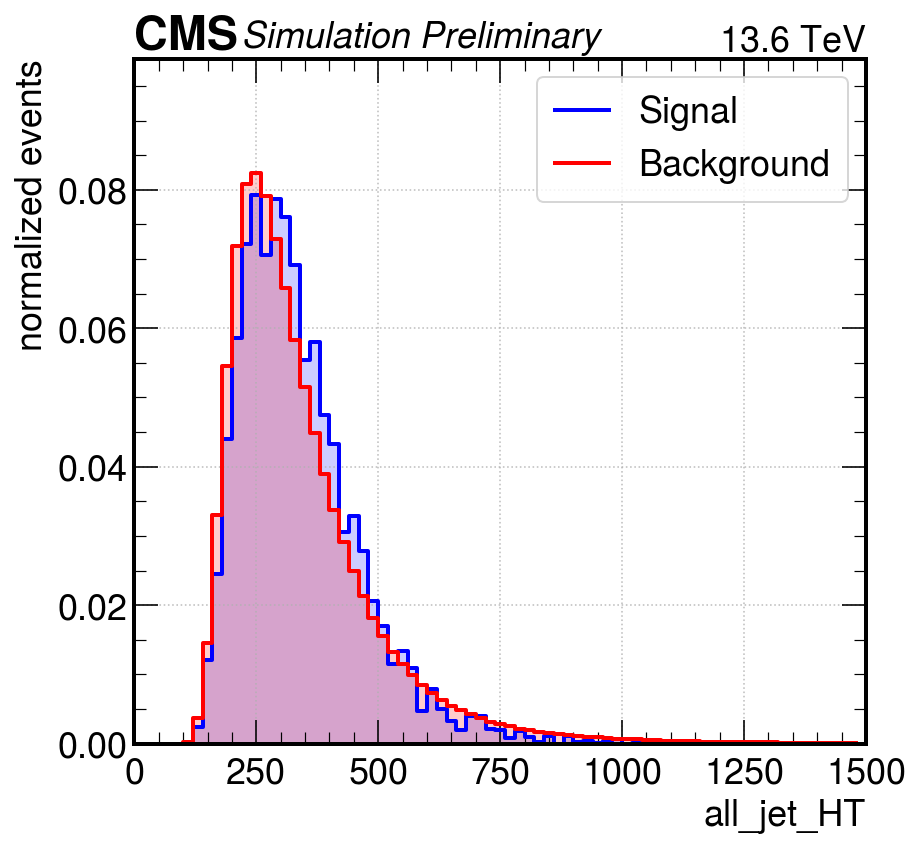

Processing SL_4j_resolved___all_sT
50
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/all_sT.pdf


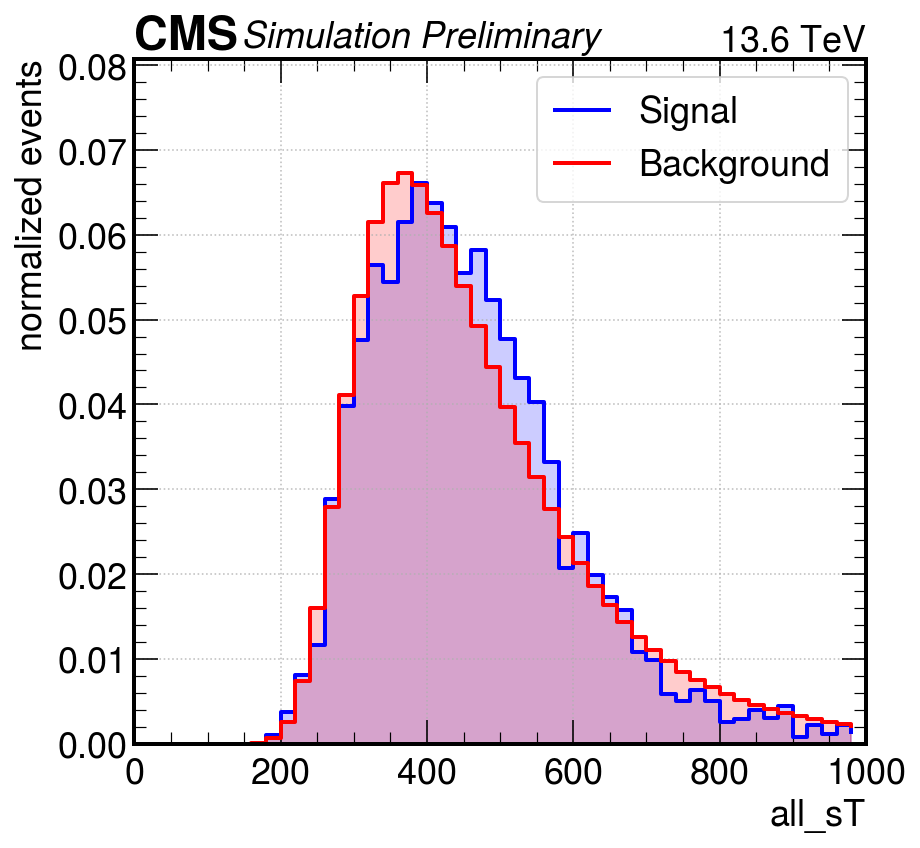

Processing SL_4j_resolved___bb_lnu_dPhi
50
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/bb_lnu_dPhi.pdf


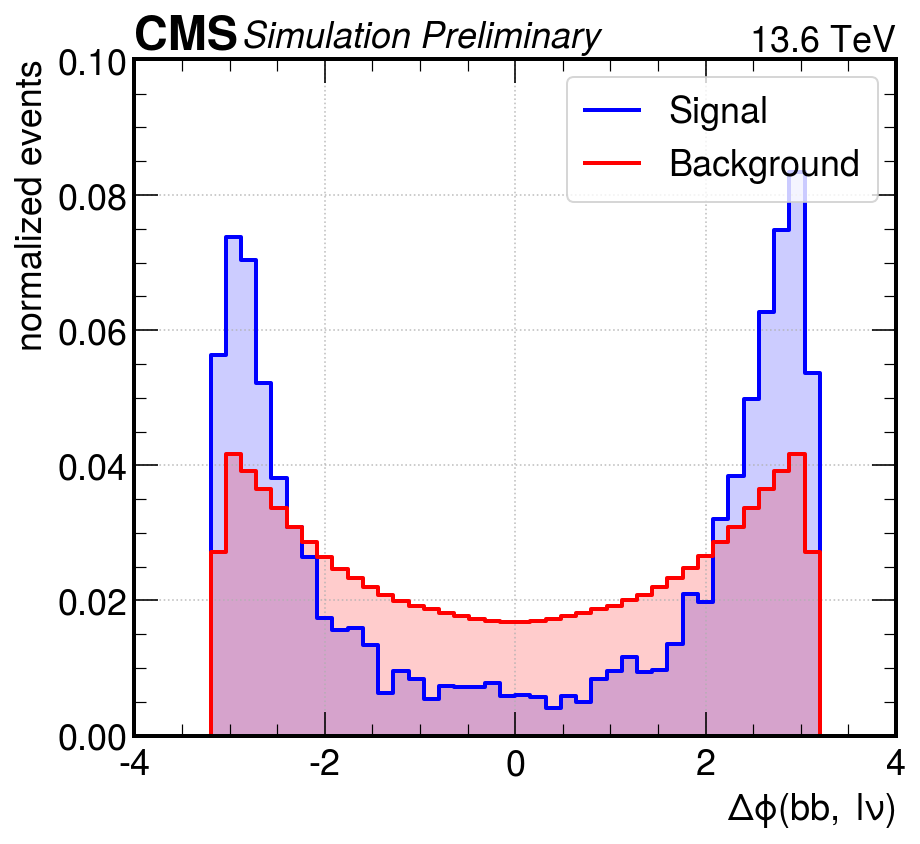

Processing SL_4j_resolved___bb_lnu_dR
50
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/bb_lnu_dR.pdf


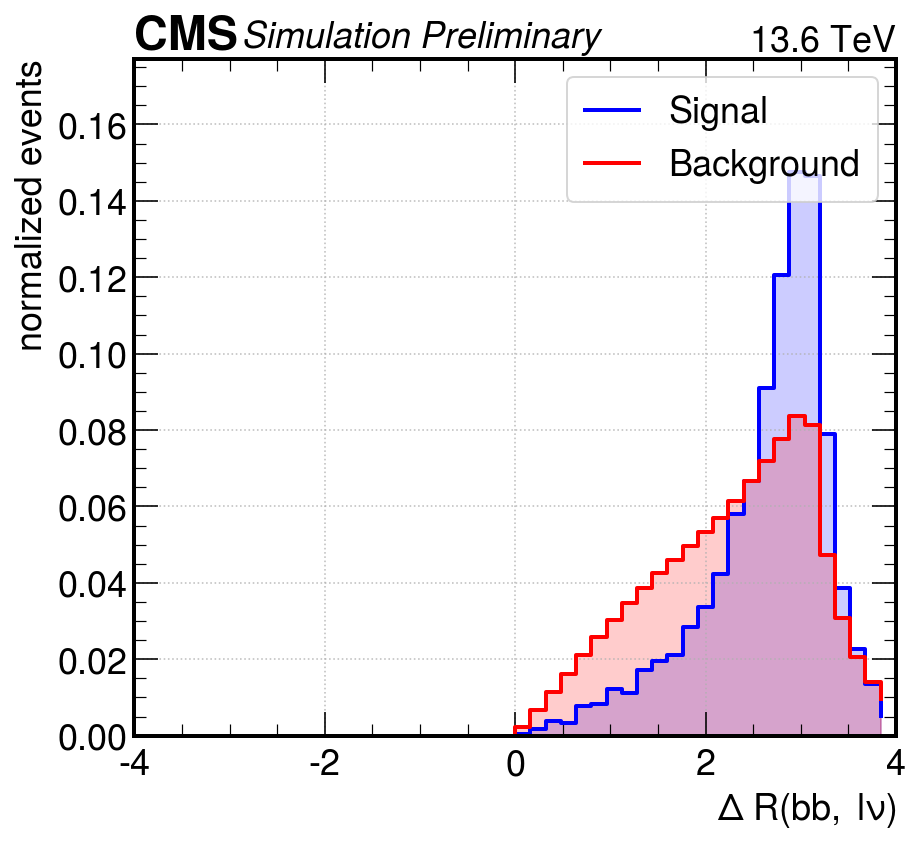

Processing SL_4j_resolved___bjet_bijet_dR
50
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/bjet_bijet_dR.pdf


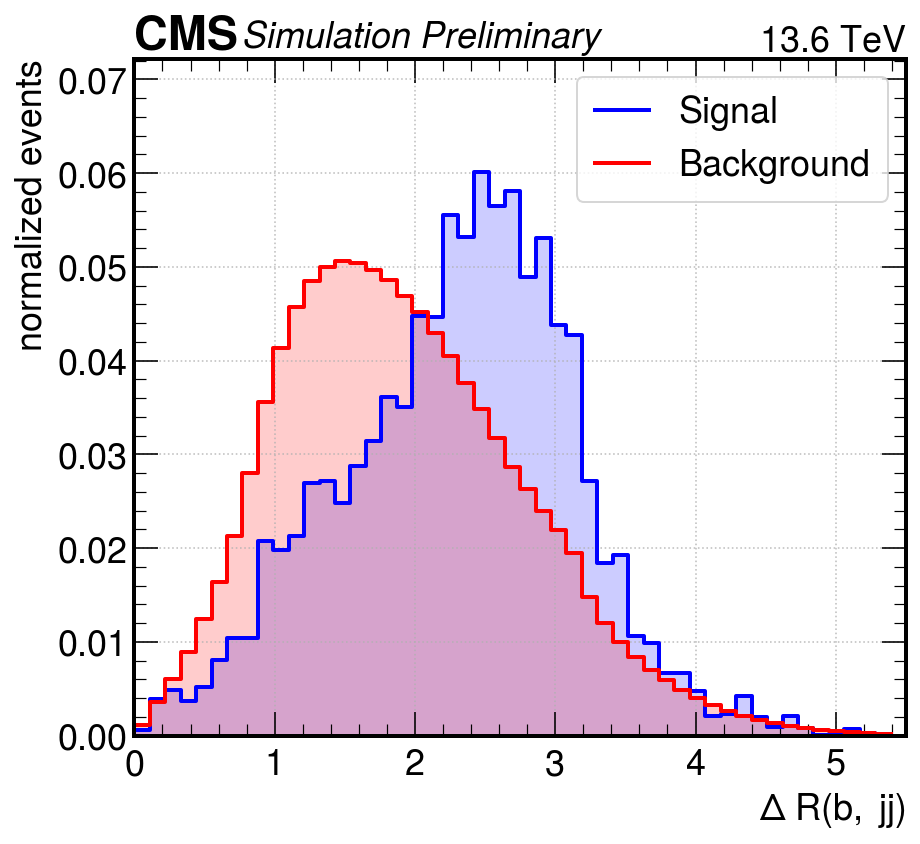

Processing SL_4j_resolved___bjets_dEta
50
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/bjets_dEta.pdf


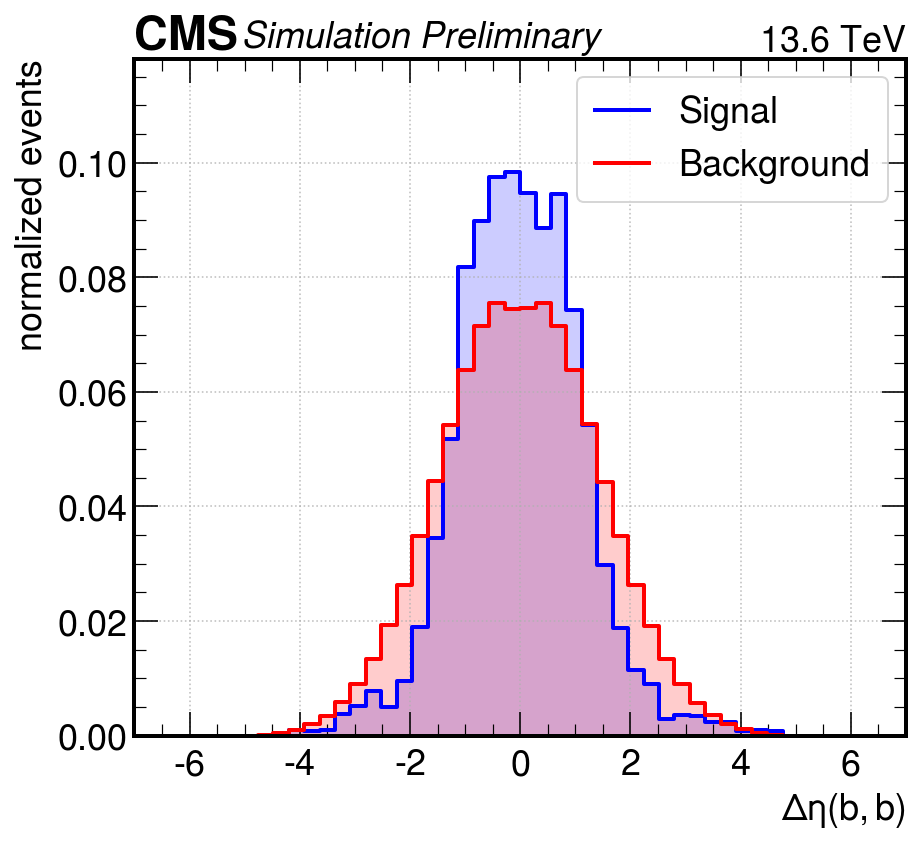

Processing SL_4j_resolved___bjets_dPhi
50
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/bjets_dPhi.pdf


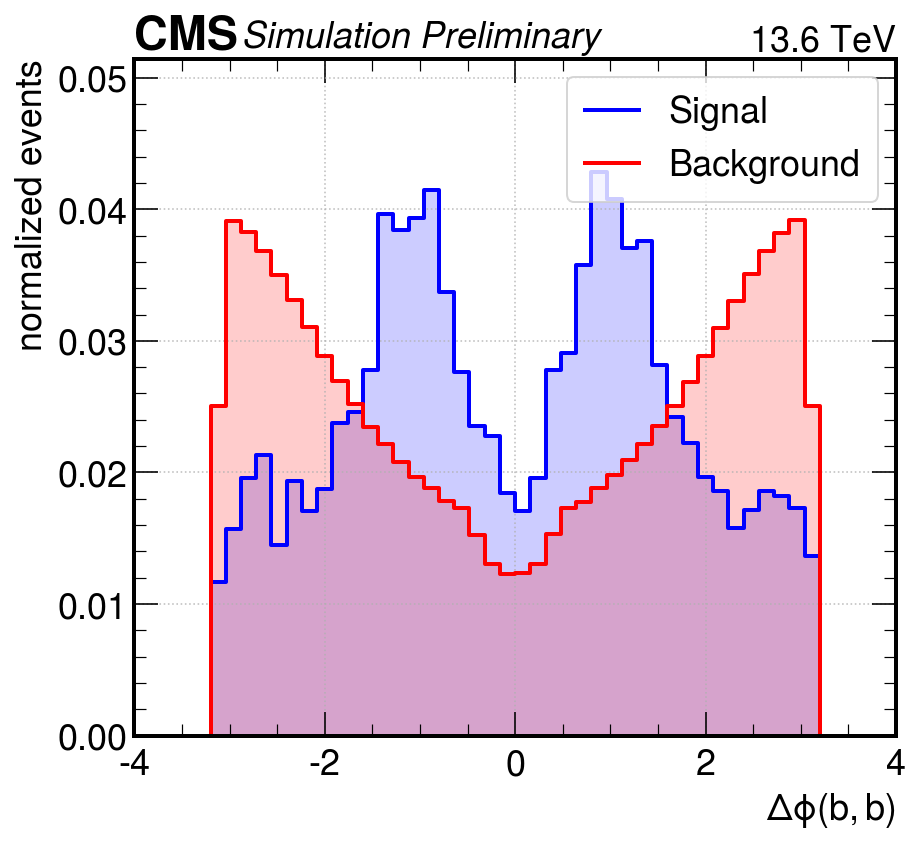

Processing SL_4j_resolved___bjets_dR
50
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/bjets_dR.pdf


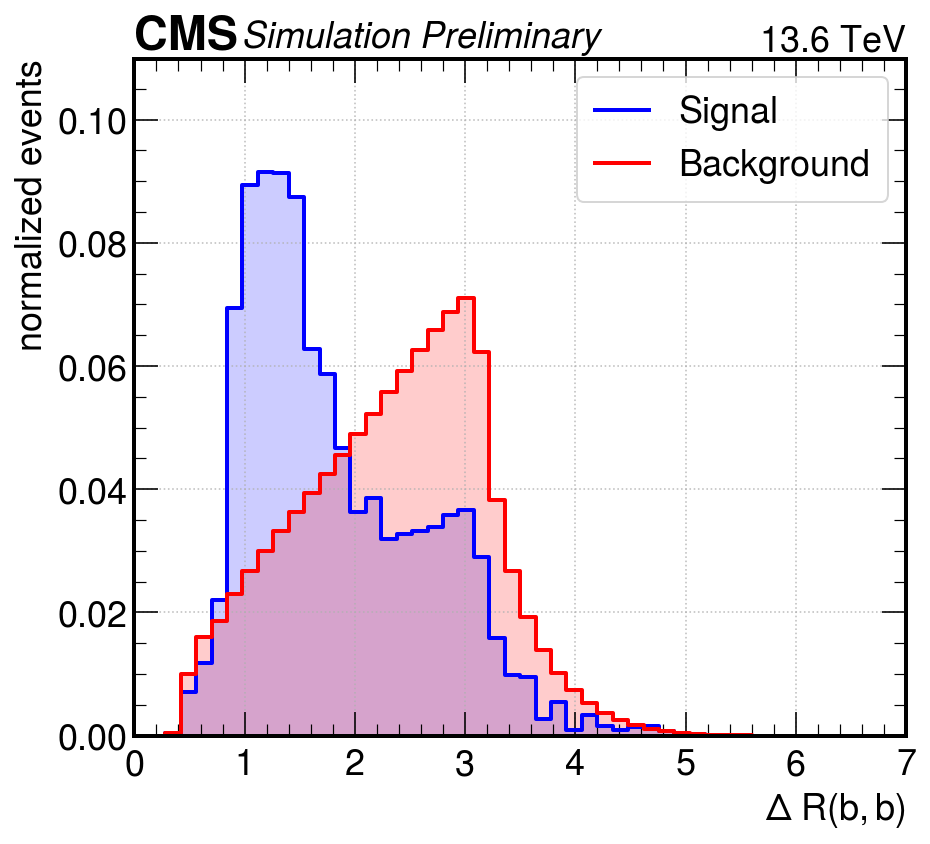

Processing SL_4j_resolved___bjets_mbb
50
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/bjets_mbb.pdf


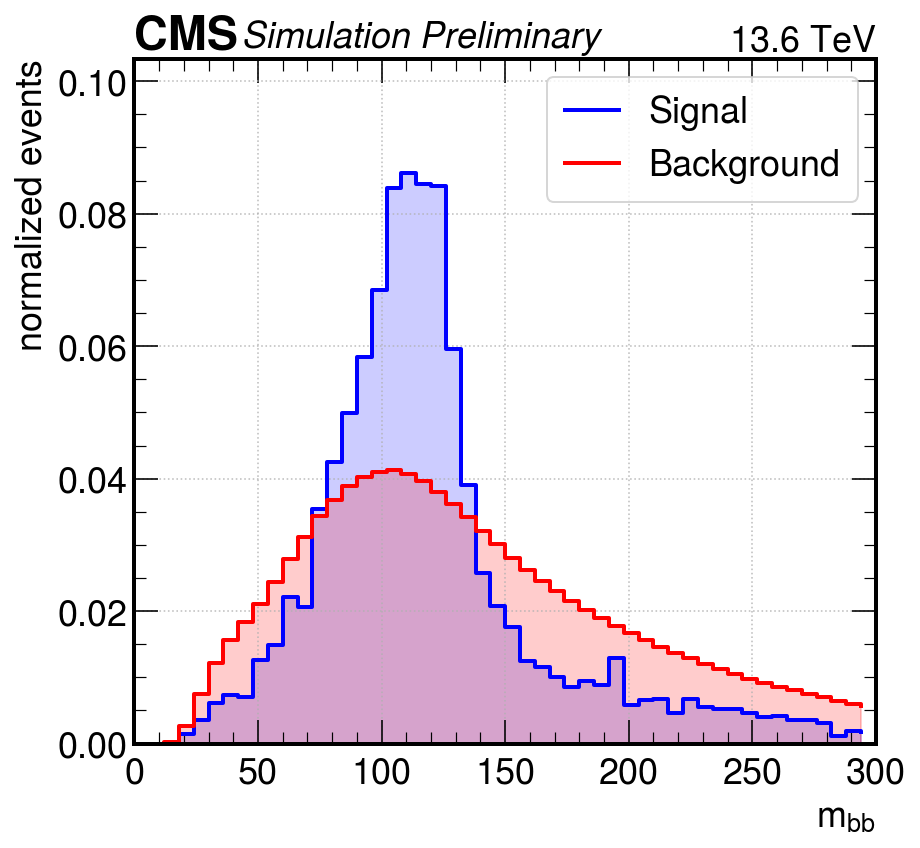

/tmp/anunezde/ipykernel_1699937/1735505279.py:64: RuntimeWarning: divide by zero encountered in log
  lr_vals = np.log(ratio_vals)


LLR Function saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/bjets_mbb_function.pdf


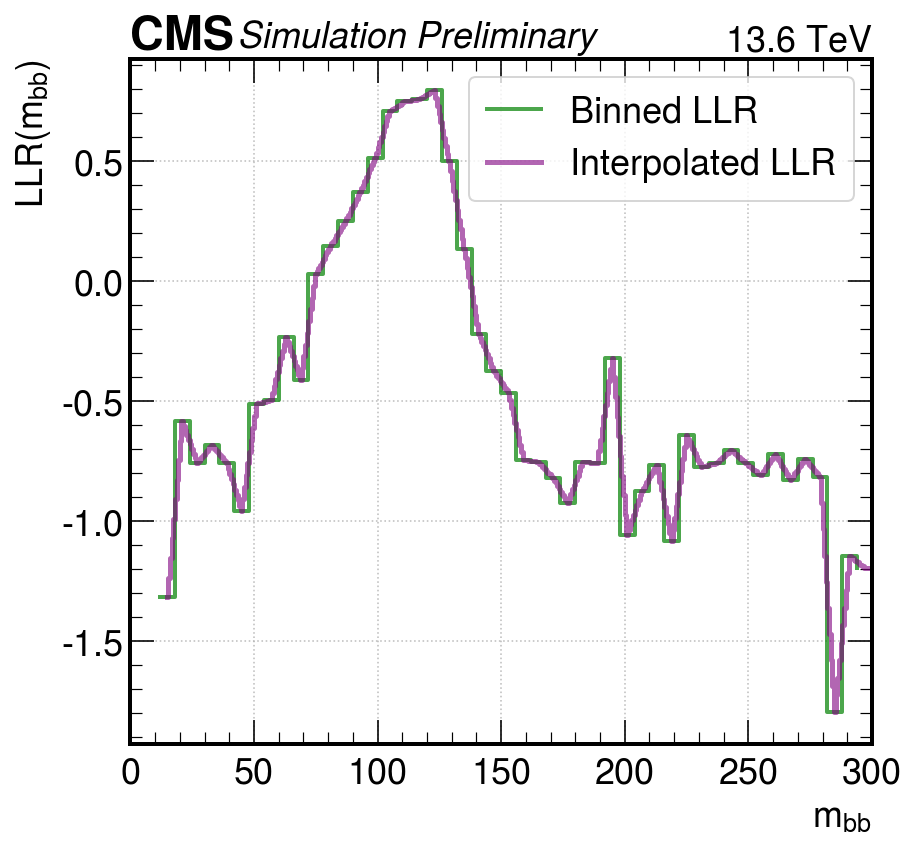

Processing SL_4j_resolved___bjets_mean_pt
30
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/bjets_mean_pt.pdf


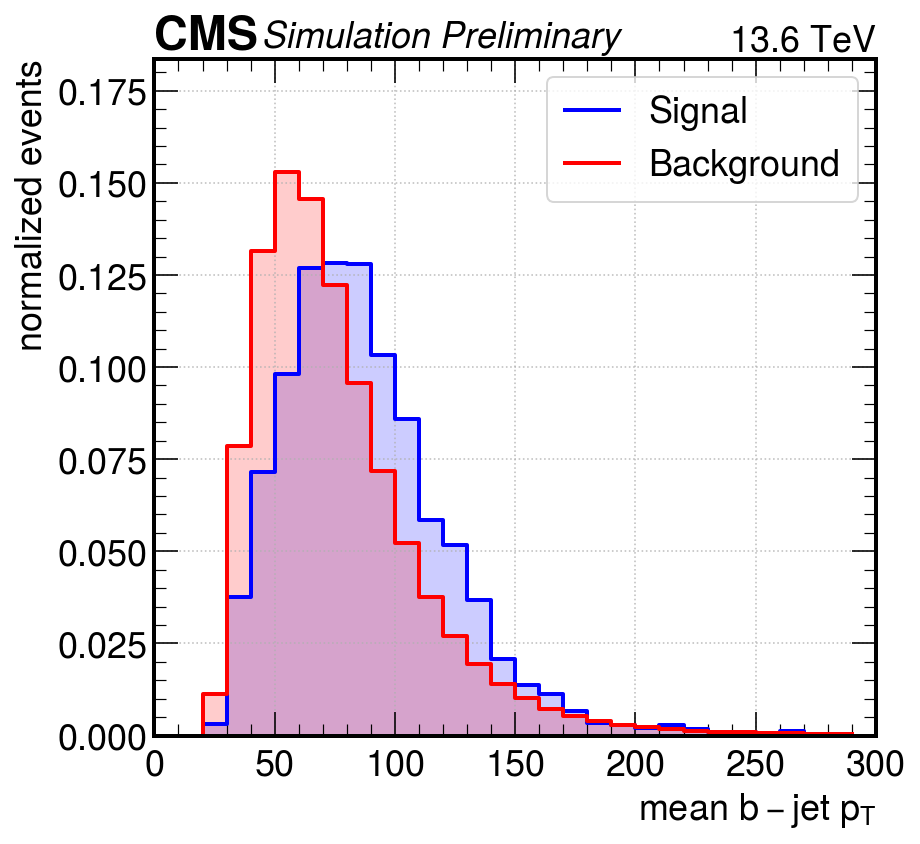

Processing SL_4j_resolved___bjets_pt_bb
50
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/bjets_pt_bb.pdf


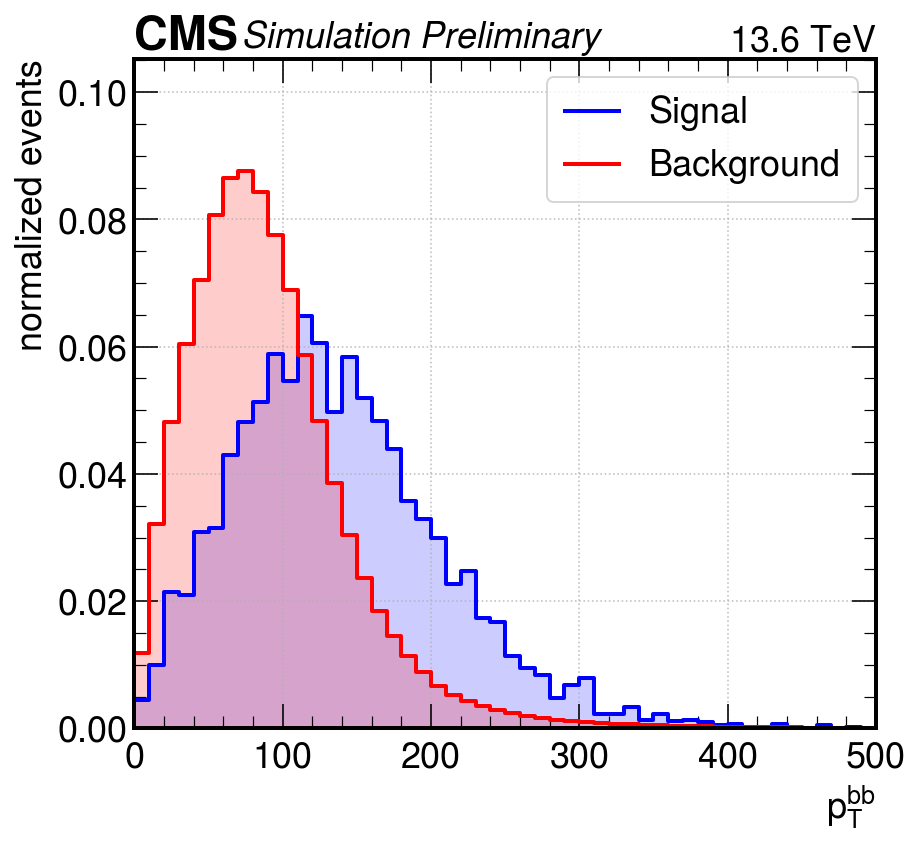

Processing SL_4j_resolved___blnu_mT
50
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/blnu_mT.pdf


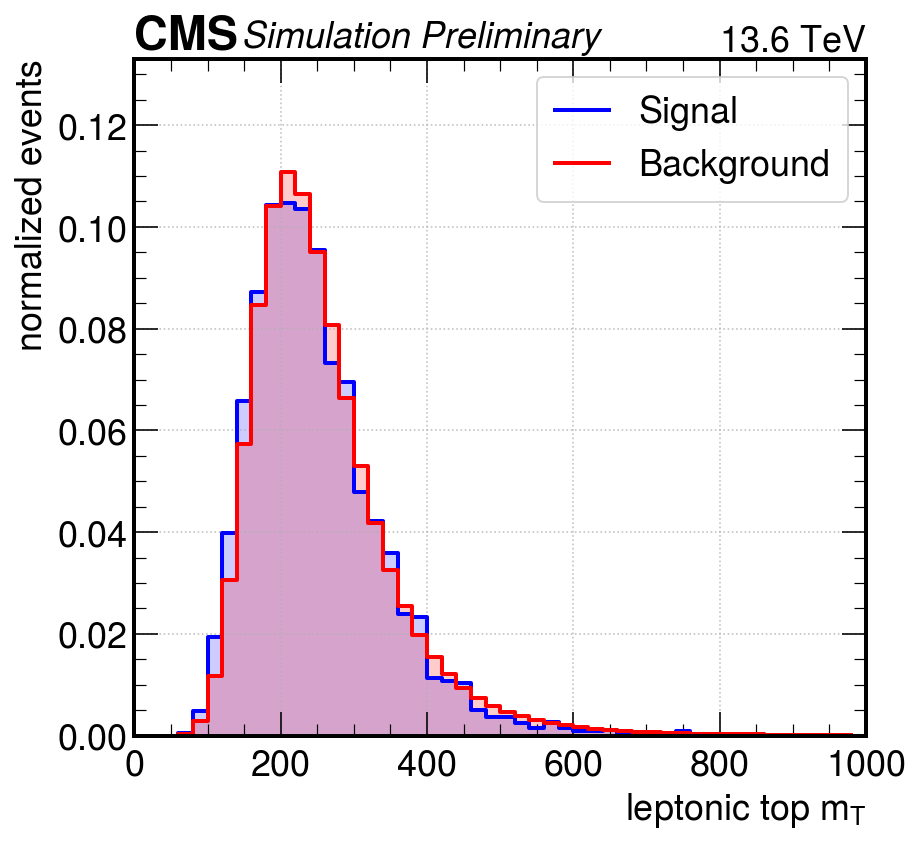

Processing SL_4j_resolved___blnu_pt
40
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/blnu_pt.pdf


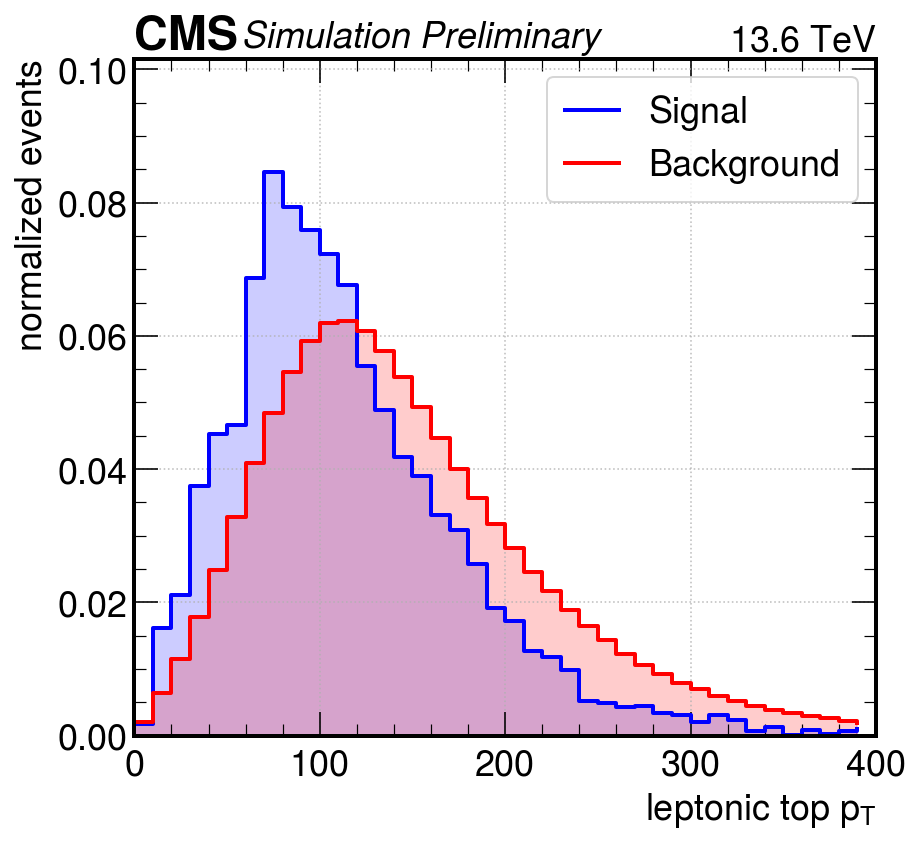

Processing SL_4j_resolved___jj_lnu_dPhi
50
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/jj_lnu_dPhi.pdf


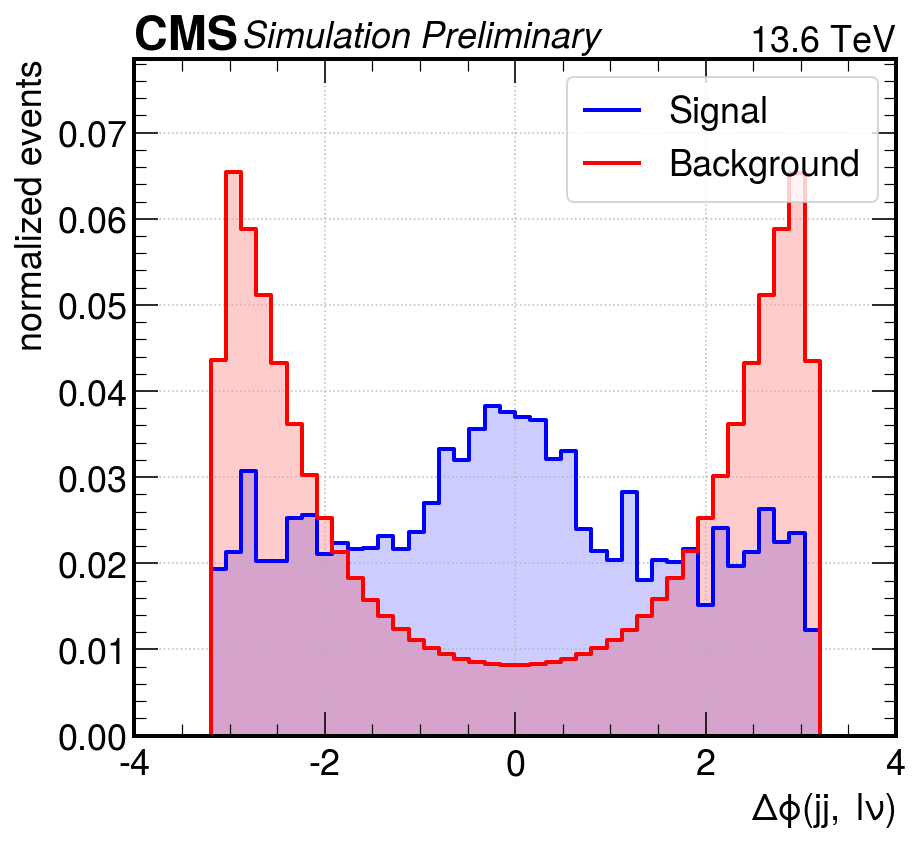

Processing SL_4j_resolved___met_pt
50
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/met_pt.pdf


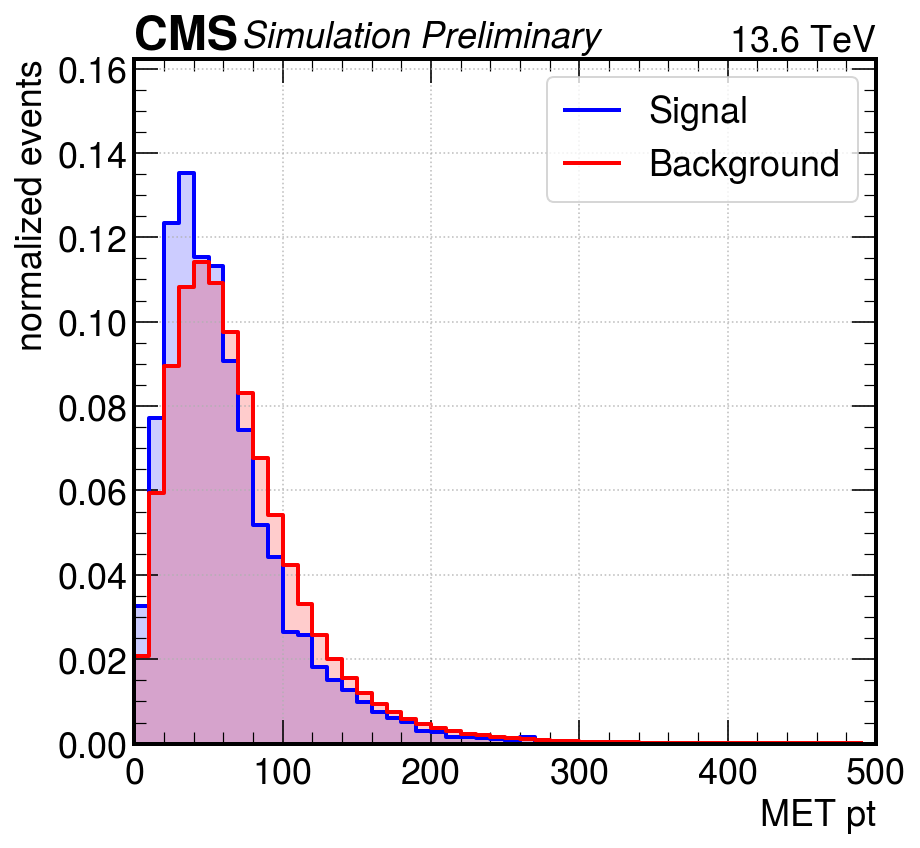

Processing SL_4j_resolved___trijet_bijet_dEta
50
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/trijet_bijet_dEta.pdf


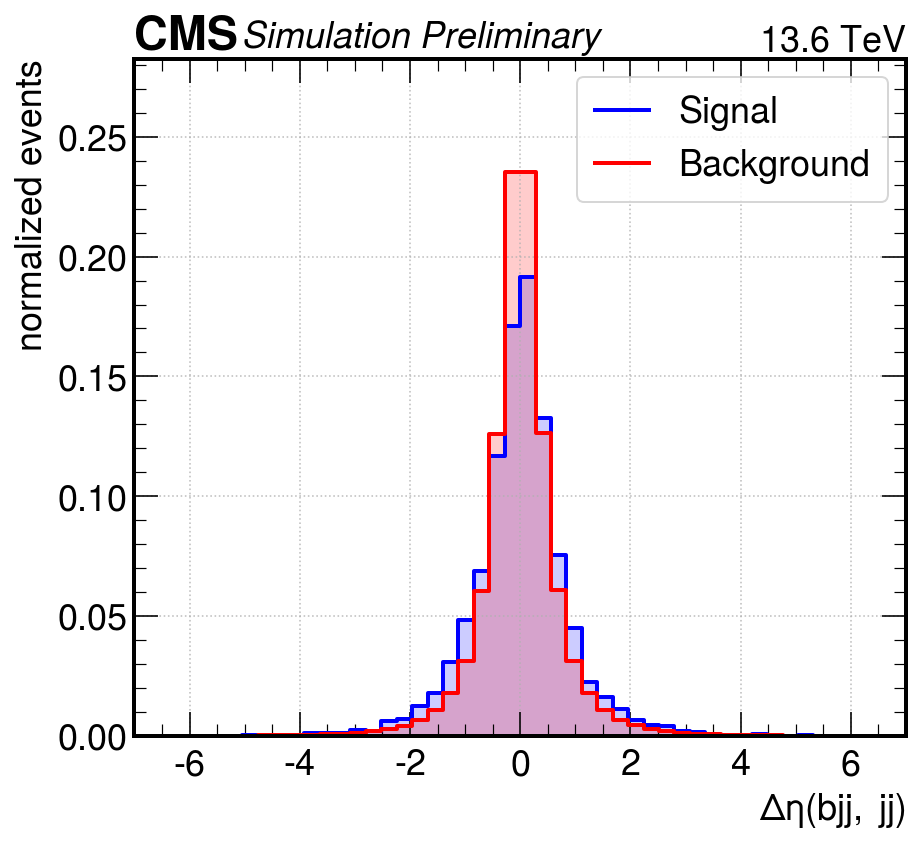

In [8]:
for ref in refs:
    print(f'Processing {ref.name}')
    process_hists = get_process_hists(ref, processes, eras, resultsdir, config)
    signal_hist = process_hists.pop('ggHH_kl_1_kt_1_bbww')
    background_hist = add_hists([hist for proc, hist in process_hists.items() if functions.process_is_bkg(proc)])
    normalized_signal = normalize_hist(signal_hist)
    normalized_background = normalize_hist(background_hist)
    ratio_hist = normalized_signal.Clone()
    ratio_hist.Divide(normalized_background)
    nbin, xmin, xmax = REG.get_var1D_binning(ref.observable_base)
    xlabel = REG.get_var1D_title(ref.observable_base)
    xlabel_formatted = format_label_for_matplotlib(xlabel)
    save_to = workdir / f"{ref.observable_base}.pdf"
    plot_signal_background(normalized_signal,  normalized_background, xlabel_formatted, xmin, xmax, save_to)
    if ref.observable_base == 'bjets_mbb':
        mapping_path = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/llr_functions.json')
        save_to = workdir / f"{ref.observable_base}_function.pdf"
        plot_lr_function(ratio_hist, mapping_path, f"{ref.name}_llr", True, xmin, xmax, save_to)

## LLR_crtd_odd

In [10]:
workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd')
resultsdir = workdir / 'results'
selections = ['SL_4j_resolved']

processes = functions.find_mc_processes(resultsdir)
eras = functions.get_eras(resultsdir)
refs = Reference.get_refs_from_file(functions.get_root_files(resultsdir)[0])
refs.sort(key=lambda r: (r.channel_base, r.observable_base))
refs = list(filter(lambda ref: ref.channel_base in selections, refs))

In [11]:
llrs_list = [f'{var_name}_llr' for var_name in vars_list]
refs = list(filter(lambda ref: ref.observable_base in llrs_list, refs))
for i, ref in enumerate(refs):
    print(i+1, ref.name)

1 SL_4j_resolved___all_jets_HT_llr
2 SL_4j_resolved___all_sT_llr
3 SL_4j_resolved___bb_lnu_dPhi_llr
4 SL_4j_resolved___bb_lnu_dR_llr
5 SL_4j_resolved___bjet_bijet_dR_llr
6 SL_4j_resolved___bjets_dEta_llr
7 SL_4j_resolved___bjets_dPhi_llr
8 SL_4j_resolved___bjets_dR_llr
9 SL_4j_resolved___bjets_mbb_llr
10 SL_4j_resolved___bjets_mean_pt_llr
11 SL_4j_resolved___bjets_pt_bb_llr
12 SL_4j_resolved___blnu_mT_llr
13 SL_4j_resolved___blnu_pt_llr
14 SL_4j_resolved___jj_lnu_dPhi_llr
15 SL_4j_resolved___met_pt_llr
16 SL_4j_resolved___trijet_bijet_dEta_llr


In [26]:
def plot_llr(ref, xmin, xmax):
    print(f'Processing {ref.name}')
    process_hists = get_process_hists(ref, processes, eras, resultsdir, config)
    signal_hist = process_hists.pop('ggHH_kl_1_kt_1_bbww')
    background_hist = add_hists([hist for proc, hist in process_hists.items() if functions.process_is_bkg(proc)])
    normalized_signal = normalize_hist(signal_hist)
    normalized_background = normalize_hist(background_hist)
    ratio_hist = normalized_signal.Clone()
    ratio_hist.Divide(normalized_background)
    varname = ref.observable_base.removesuffix('_llr')
    xlabel = 'LLR(' + REG.get_var1D_title(varname) + ')'
    xlabel_formatted = format_label_for_matplotlib(xlabel)
    save_to = workdir / f"{ref.observable_base}.pdf"
    plot_signal_background(normalized_signal,  normalized_background, xlabel_formatted, xmin, xmax, save_to)

Processing SL_4j_resolved___all_jets_HT_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/all_jets_HT_llr.pdf


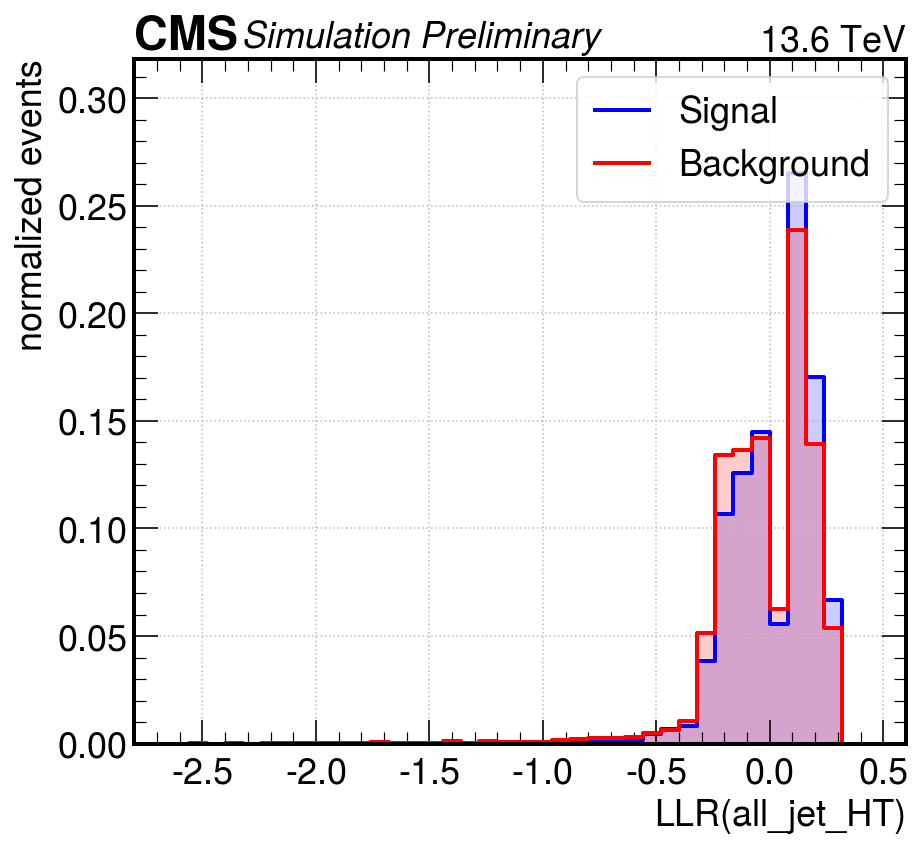

In [27]:
plot_llr(refs[0], -2.8, 0.6)

Processing SL_4j_resolved___all_sT_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/all_sT_llr.pdf


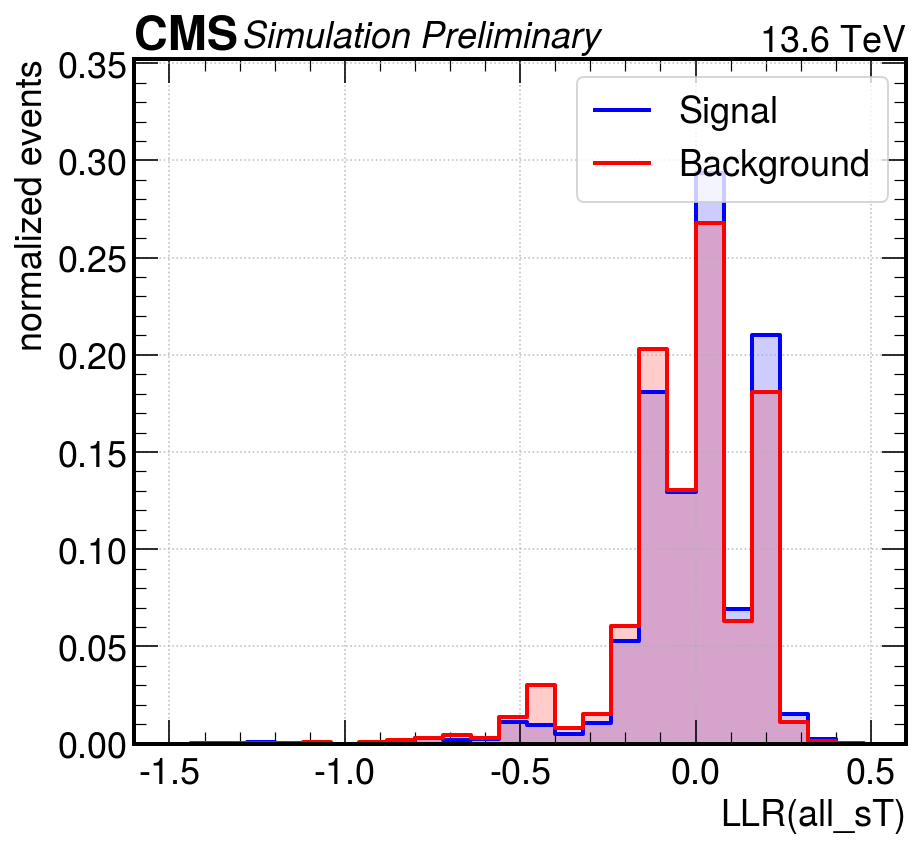

In [28]:
plot_llr(refs[1], -1.6, 0.6)

Processing SL_4j_resolved___bb_lnu_dPhi_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/bb_lnu_dPhi_llr.pdf


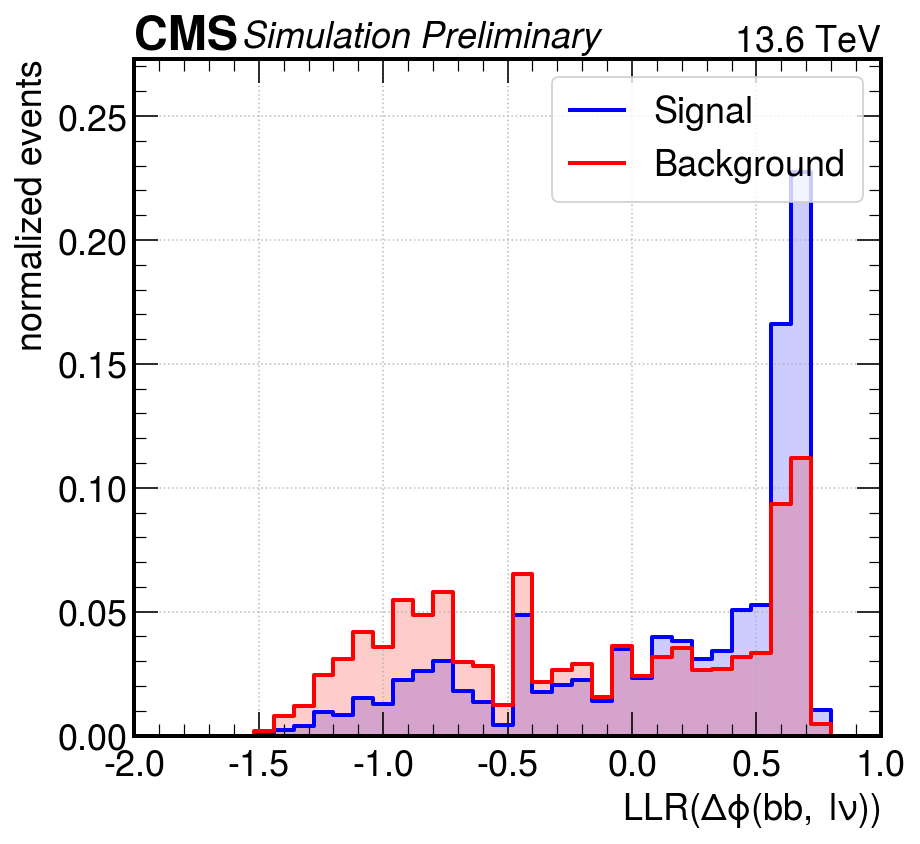

In [29]:
plot_llr(refs[2], -2, 1)

Processing SL_4j_resolved___bb_lnu_dR_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/bb_lnu_dR_llr.pdf


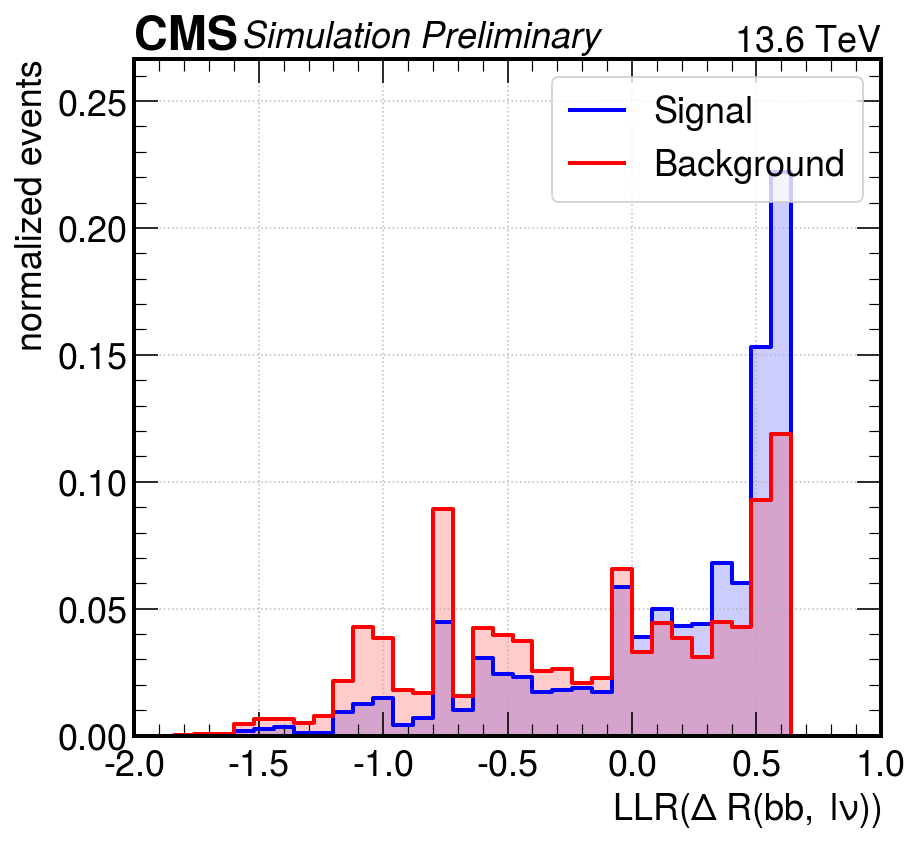

In [30]:
plot_llr(refs[3], -2, 1)

Processing SL_4j_resolved___bjet_bijet_dR_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/bjet_bijet_dR_llr.pdf


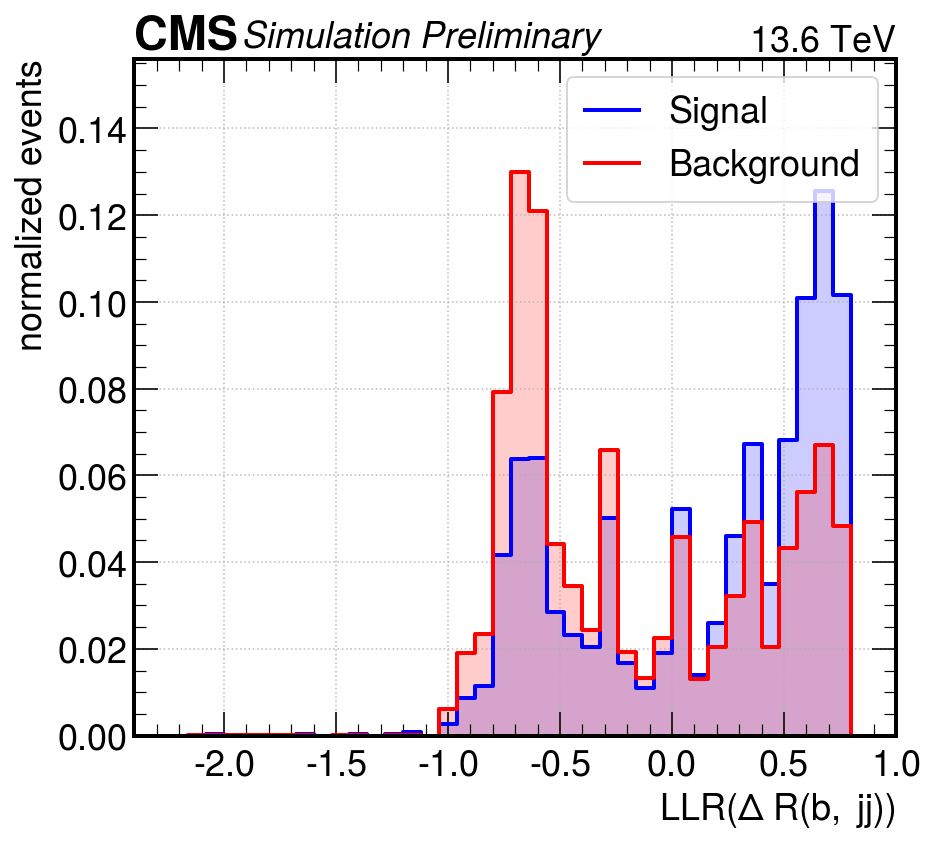

In [34]:
plot_llr(refs[4], -2.4, 1)

Processing SL_4j_resolved___bjets_dEta_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/bjets_dEta_llr.pdf


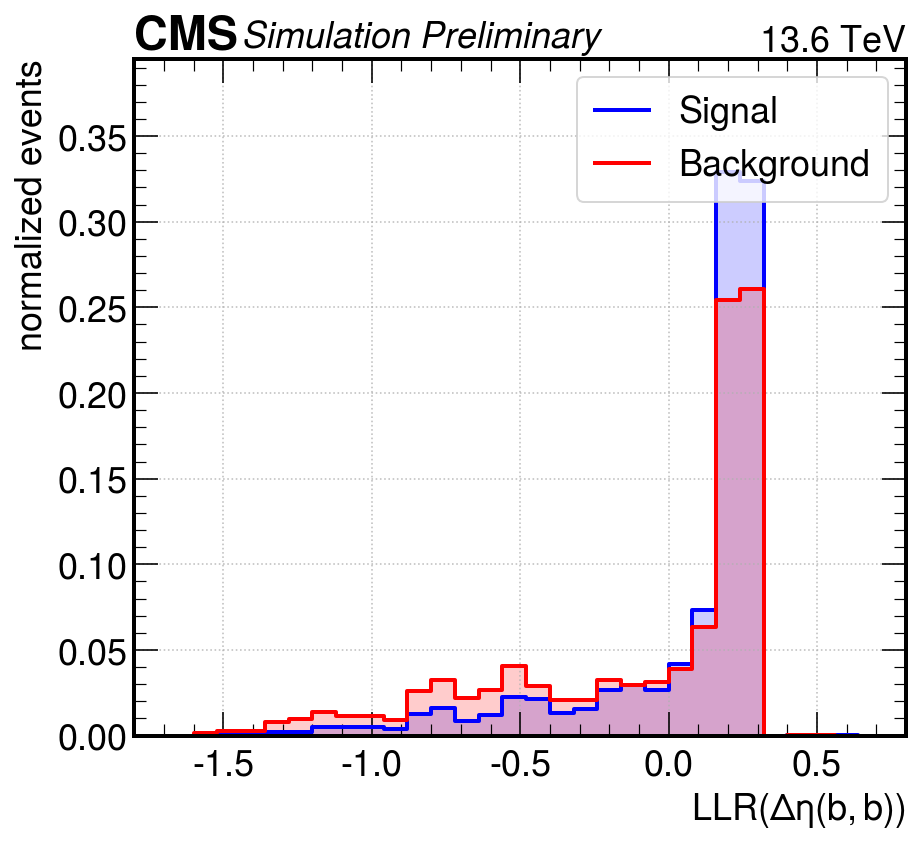

In [36]:
plot_llr(refs[5], -1.8, 0.8)

Processing SL_4j_resolved___bjets_dPhi_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/bjets_dPhi_llr.pdf


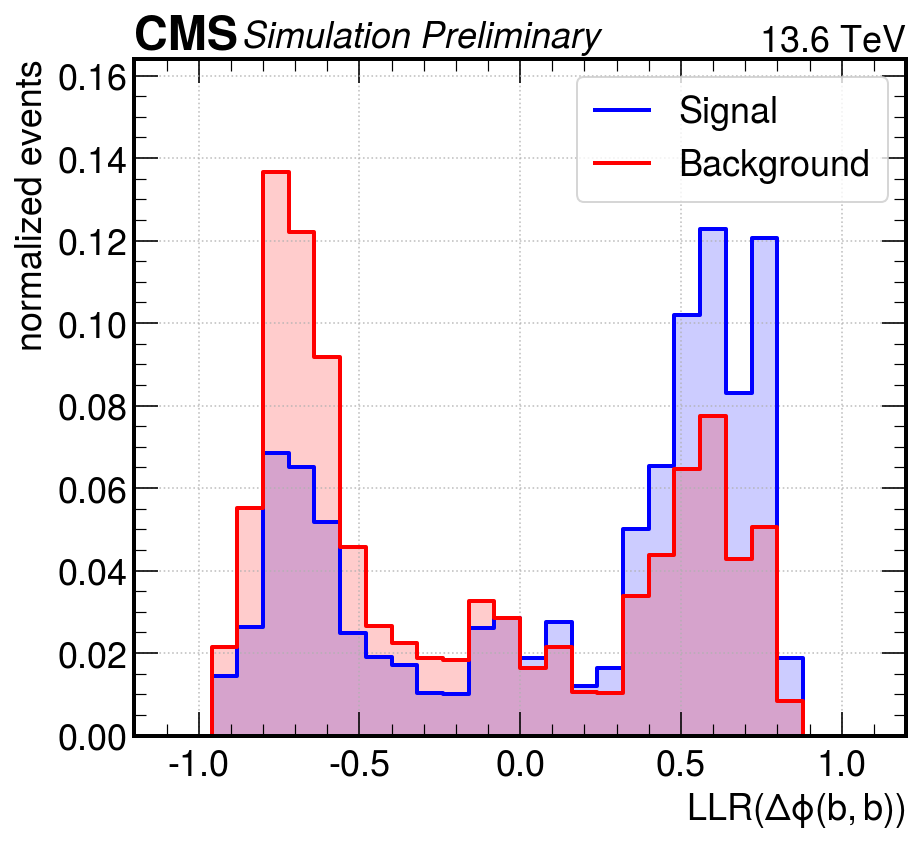

In [39]:
plot_llr(refs[6], -1.2, 1.2)

Processing SL_4j_resolved___bjets_dR_llr


100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/bjets_dR_llr.pdf


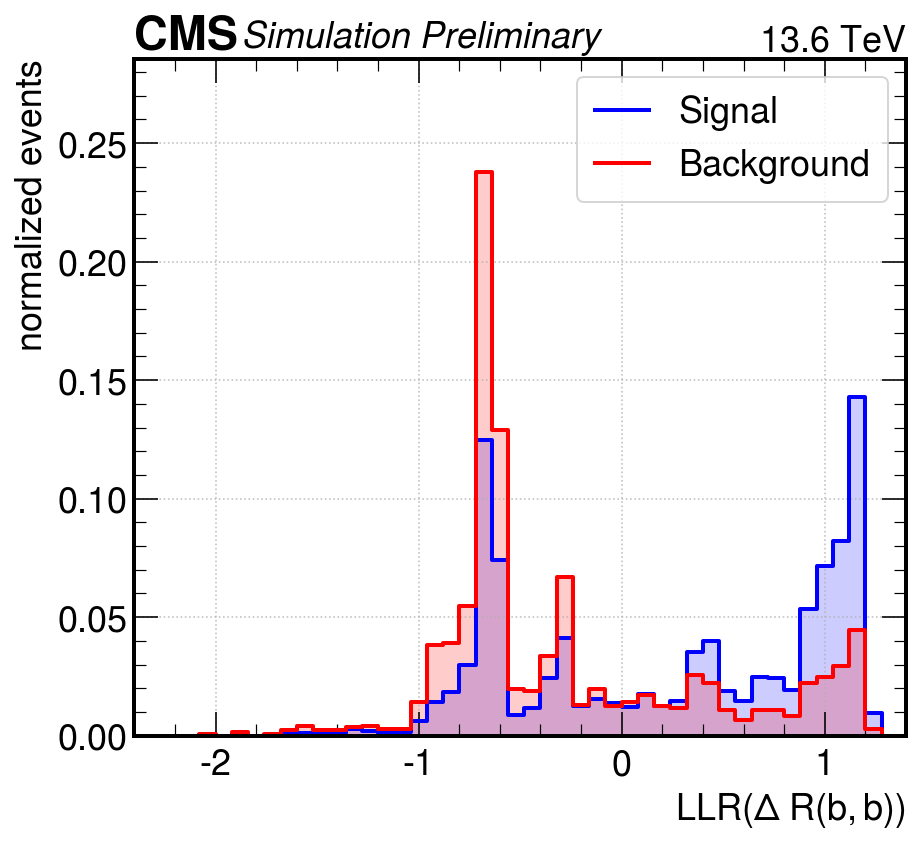

In [43]:
plot_llr(refs[7], -2.4, 1.4)

Processing SL_4j_resolved___bjets_mbb_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/bjets_mbb_llr.pdf


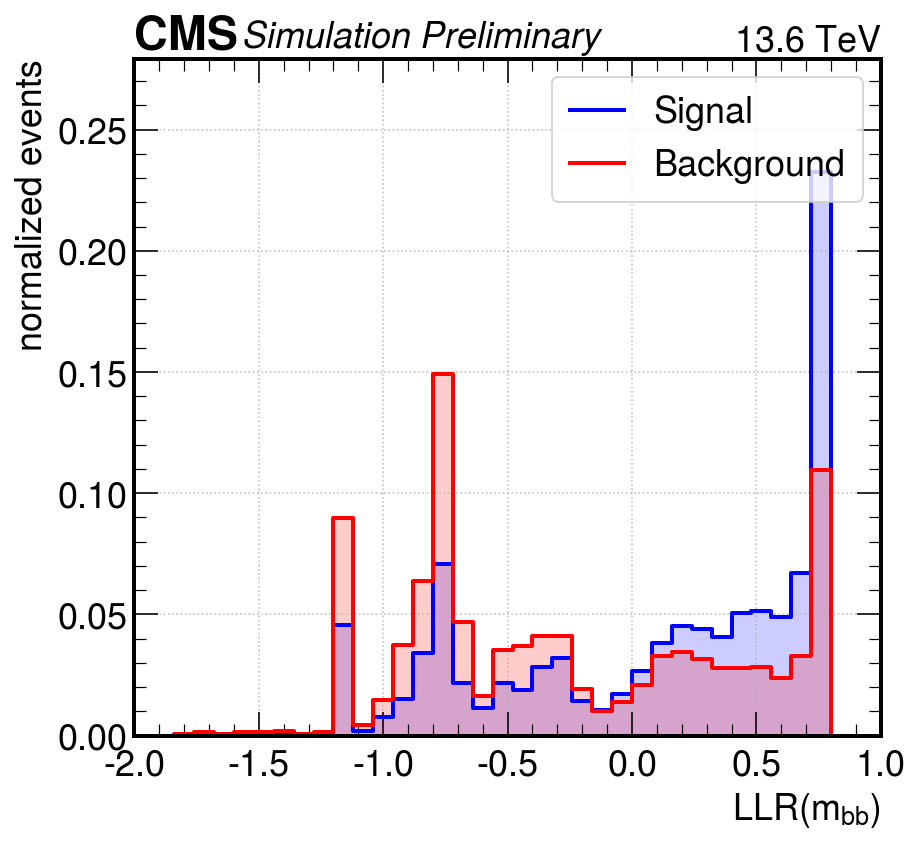

In [45]:
plot_llr(refs[8], -2, 1)

Processing SL_4j_resolved___bjets_mean_pt_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/bjets_mean_pt_llr.pdf


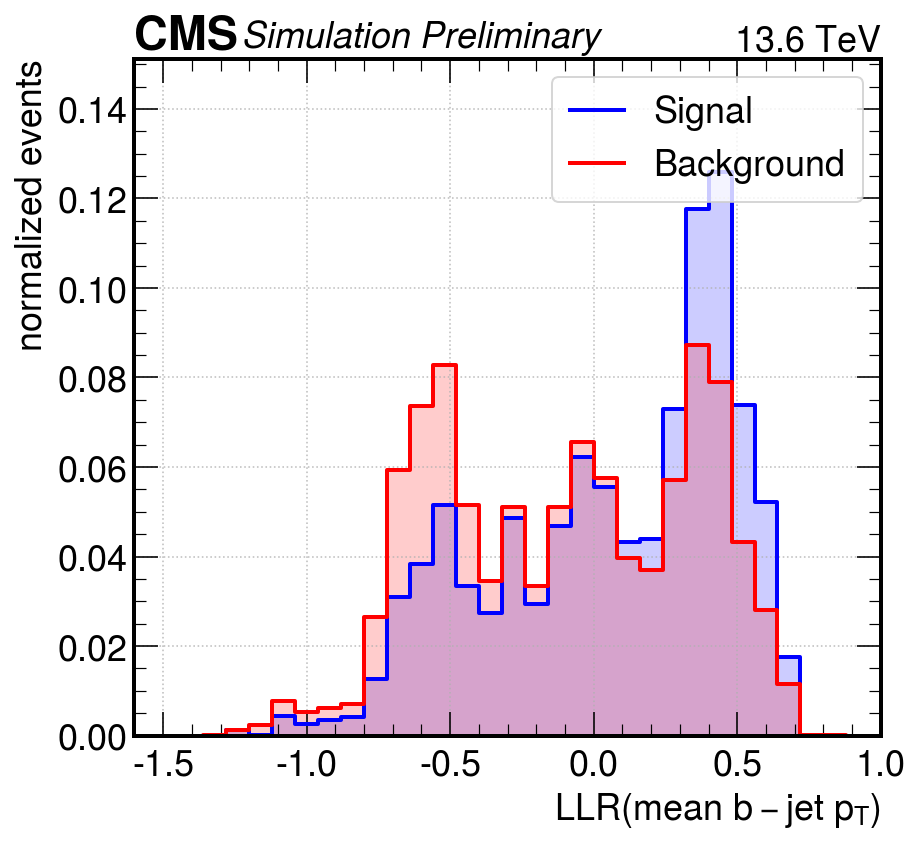

In [47]:
plot_llr(refs[9], -1.6, 1)

Processing SL_4j_resolved___bjets_pt_bb_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/bjets_pt_bb_llr.pdf


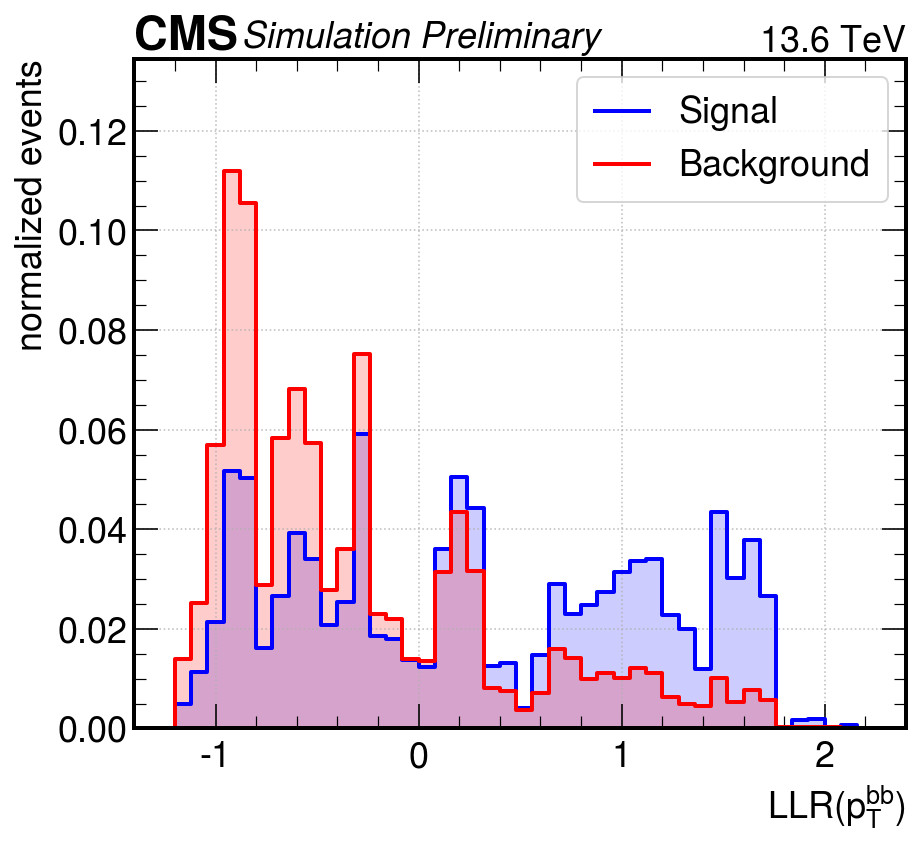

In [51]:
plot_llr(refs[10], -1.4, 2.4)

Processing SL_4j_resolved___blnu_mT_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/blnu_mT_llr.pdf


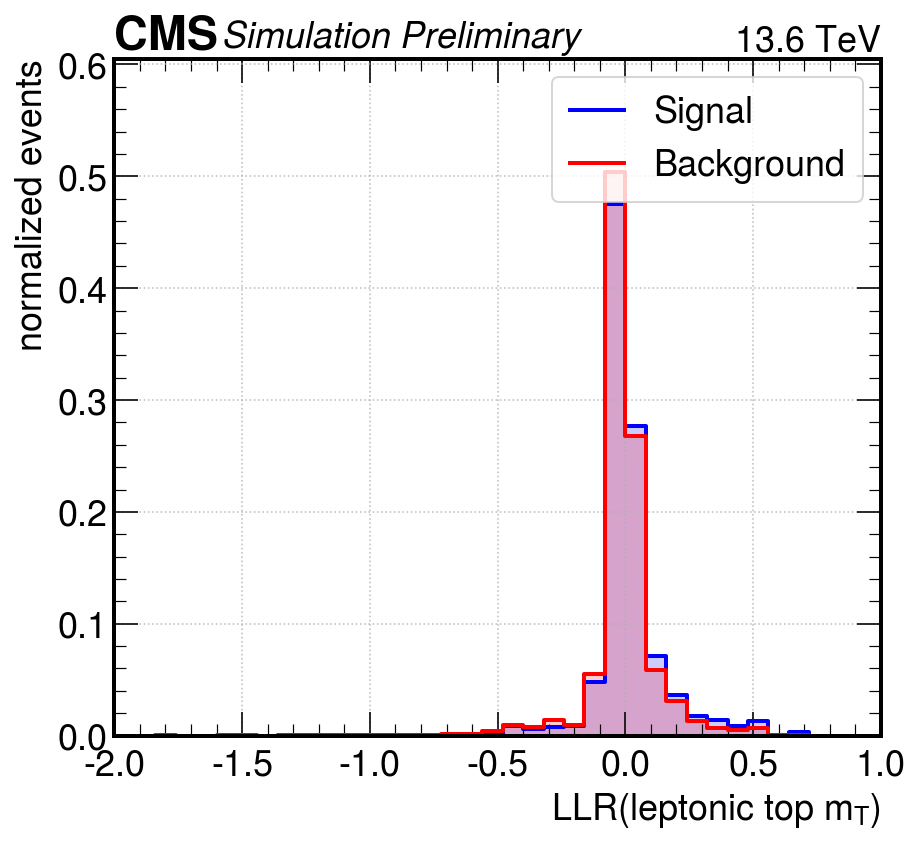

In [53]:
plot_llr(refs[11], -2, 1)

Processing SL_4j_resolved___blnu_pt_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/blnu_pt_llr.pdf


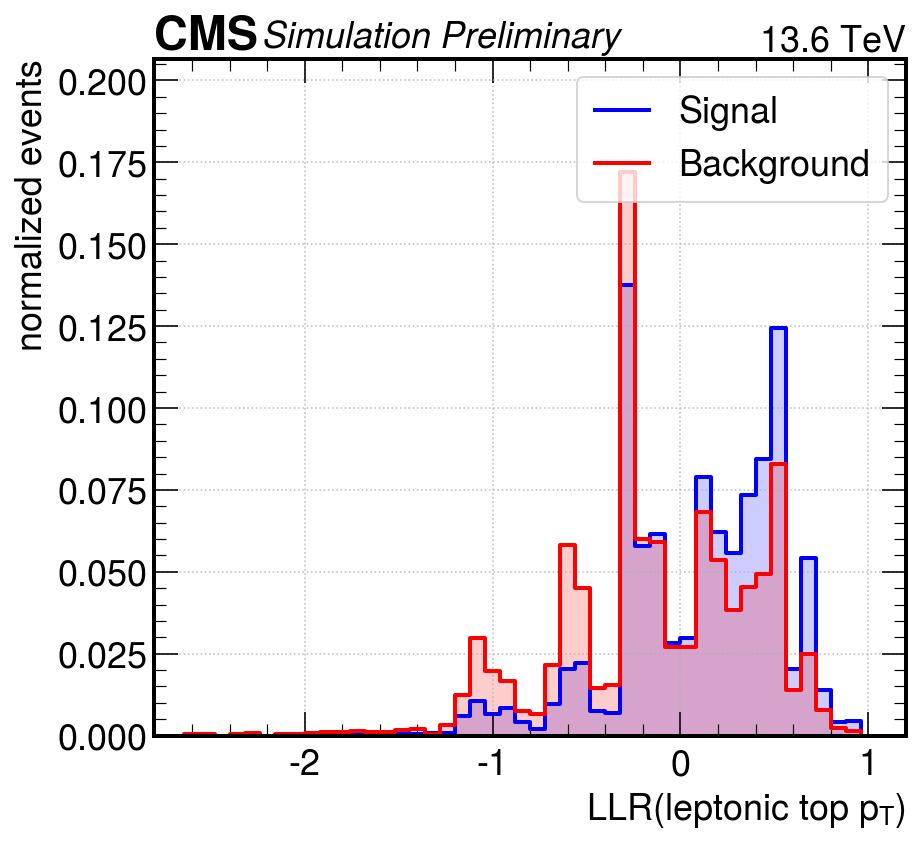

In [56]:
plot_llr(refs[12], -2.8, 1.2)

Processing SL_4j_resolved___jj_lnu_dPhi_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/jj_lnu_dPhi_llr.pdf


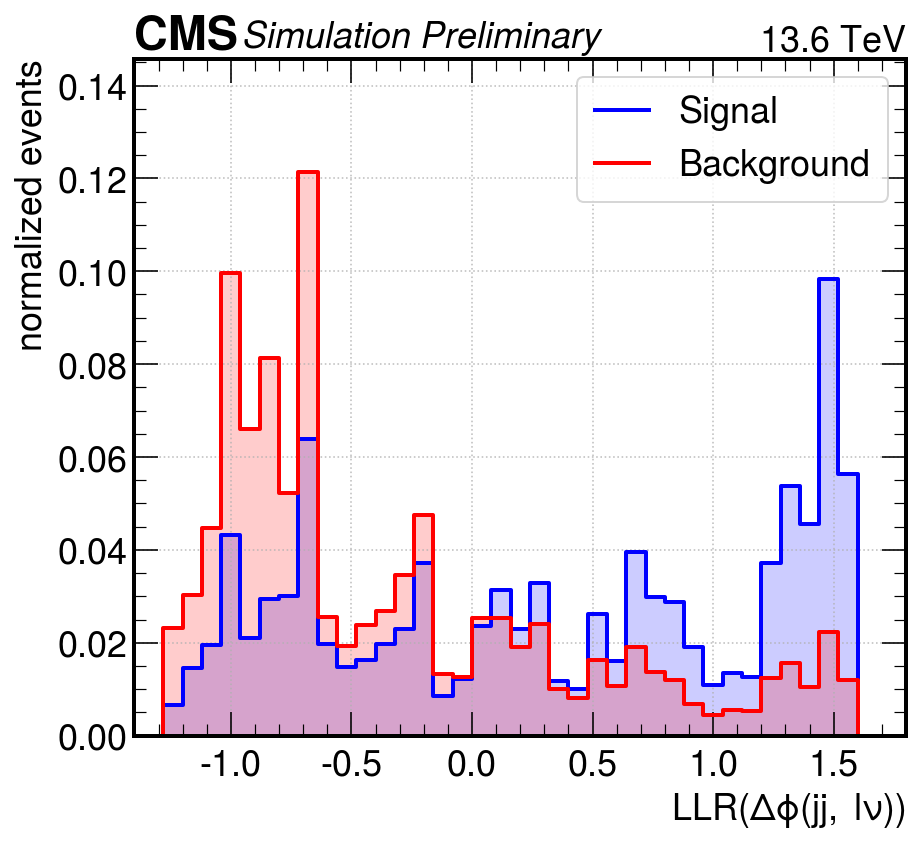

In [60]:
plot_llr(refs[13], -1.4, 1.8)

Processing SL_4j_resolved___met_pt_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/met_pt_llr.pdf


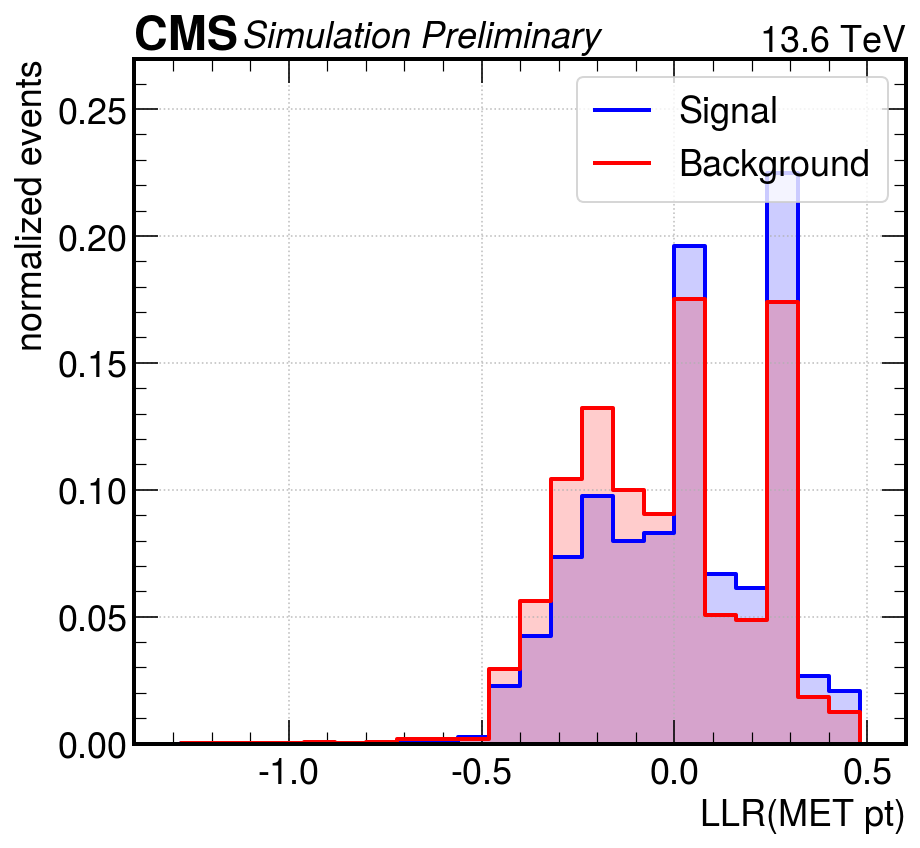

In [62]:
plot_llr(refs[14], -1.4, 0.6)

Processing SL_4j_resolved___trijet_bijet_dEta_llr
100
Distribution sig/bkg saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd/trijet_bijet_dEta_llr.pdf


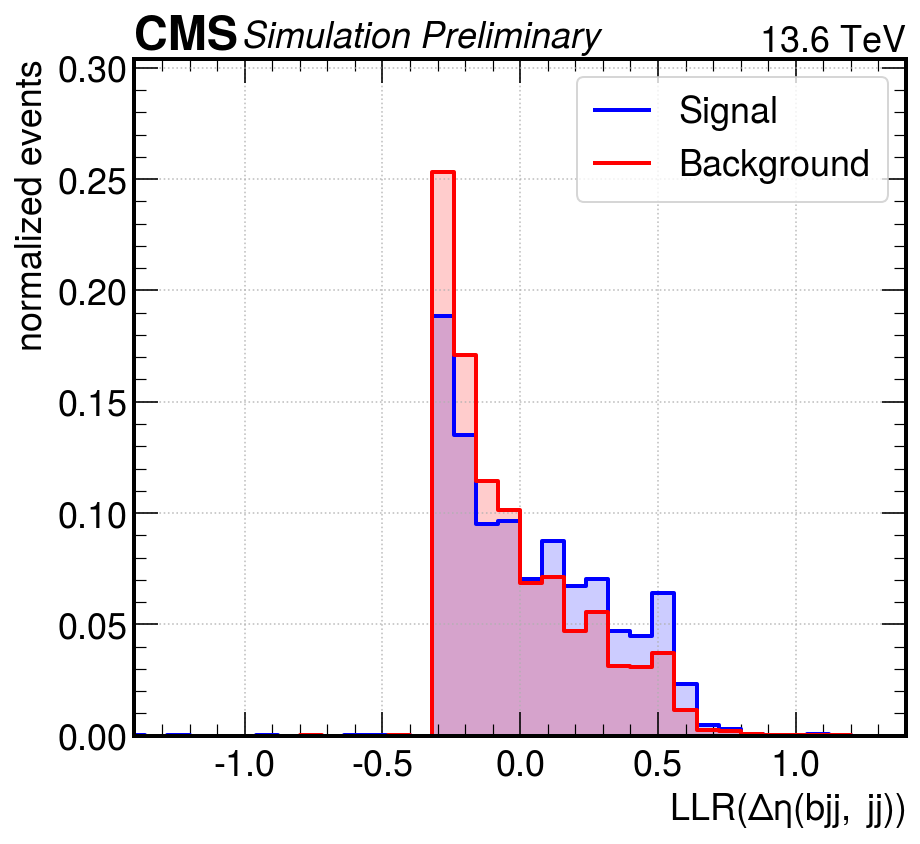

In [65]:
plot_llr(refs[15], -1.4, 1.4)